# Figure 1 — Storm Tracks & Vmax vs. Distance-to-Coast

**Two-panel layout**
- **(a)** Vmax (`USA_WIND`, 1-min kt) vs. hours-to-impact, aligned on t_closest = 0  
- **(b)** Storm tracks on a map, colour-coded by Vmax, with impact reference stars  

**Answers Q2**: How does Vmax change as a function of distance-to-coast in the final 500–1000 km?  
**Prerequisite**: `data/ibtracs/{storm}_track.csv` (run `01_track_analysis.ipynb` first).

## 1 — Setup

In [1]:
import os, sys, warnings
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils import IBTRACS_DIR, FIG_DIR, STORM_ORDER, STORMS, ensure_dirs

ensure_dirs()
OUTPATH = os.path.join(FIG_DIR, 'track_vmax.png')

## 2 — Load track data

In [2]:
tracks = {}
for key in STORM_ORDER:
    p = os.path.join(IBTRACS_DIR, f'{key}_track.csv')
    if os.path.exists(p):
        tracks[key] = pd.read_csv(p, parse_dates=['ISO_TIME'])
        print(f'Loaded {key}: {len(tracks[key])} rows')
    else:
        print(f'Missing: {p}')

assert tracks, 'No track data found — run 01_track_analysis.ipynb first.'

Loaded ragasa: 49 rows
Loaded mangkhut: 99 rows
Loaded maria: 131 rows
Loaded dorian: 133 rows


## 3 — Panel (a): Vmax timeline

In [3]:
def plot_vmax_timeline(ax):
    for key in STORM_ORDER:
        if key not in tracks:
            continue
        df   = tracks[key]
        meta = STORMS[key]
        lbl  = f"{meta['name']} ({meta['year']}, {meta['basin']})"
        ax.plot(df['hours_to_impact'], df['USA_WIND'],
                color=meta['color'], linestyle=meta['linestyle'],
                linewidth=2, label=lbl)
        # Peak marker
        idx = df['USA_WIND'].idxmax()
        ax.scatter(df.loc[idx, 'hours_to_impact'], df.loc[idx, 'USA_WIND'],
                   color=meta['color'], s=80, zorder=5, edgecolors='k', linewidths=0.7)

    ax.axvline(0, color='0.4', linestyle=':', linewidth=1.2, label='t_closest')
    ax.axvspan(-40, 0, alpha=0.06, color='red')   # approx final 500 km shading
    ax.set_xlim(-96, 48)
    ax.set_ylim(bottom=0)
    ax.set_xlabel('Hours relative to closest approach', fontsize=10)
    ax.set_ylabel('Vmax — USA_WIND (1-min kt)', fontsize=10)
    ax.set_title('(a) Intensity trajectory near landfall', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(alpha=0.3)

## 4 — Panel (b): Storm track map

In [4]:
def plot_track_map(ax):
    ax.set_global()
    ax.add_feature(cfeature.LAND,      facecolor='0.85', zorder=1)
    ax.add_feature(cfeature.OCEAN,     facecolor='#d0e8f5', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle=':', zorder=2)
    ax.gridlines(draw_labels=False, linewidth=0.3, color='0.6')

    for key in STORM_ORDER:
        if key not in tracks:
            continue
        df   = tracks[key]
        meta = STORMS[key]
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            ax.plot(df['LON'], df['LAT'], color=meta['color'],
                    linestyle=meta['linestyle'], linewidth=1.5,
                    transform=ccrs.PlateCarree(), label=meta['name'])
        ax.scatter(meta['impact_lon'], meta['impact_lat'],
                   marker='*', s=140, color=meta['color'],
                   edgecolors='k', linewidths=0.5,
                   transform=ccrs.PlateCarree(), zorder=5)

    ax.set_title('(b) Storm tracks  (★ = impact reference)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='lower left')

## 5 — Assemble and save

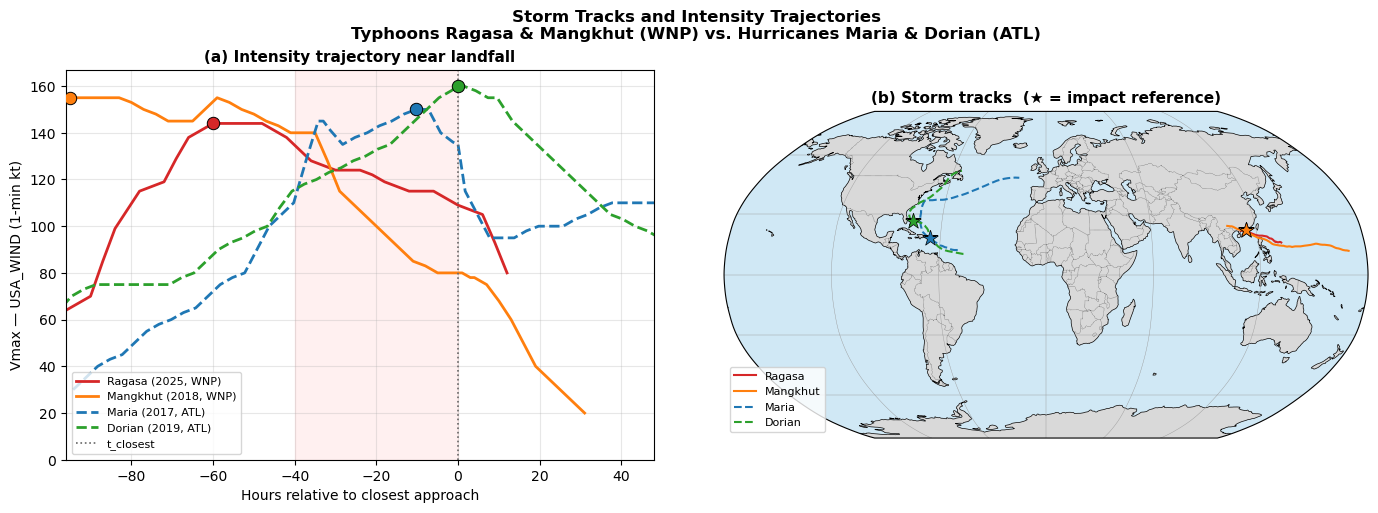

Saved → /home/sharperace/geog_1.02_final_proj/figures/track_vmax.png


In [5]:
fig = plt.figure(figsize=(14, 5))
ax_left  = fig.add_axes([0.05, 0.12, 0.42, 0.78])
ax_right = fig.add_axes([0.52, 0.05, 0.46, 0.88],
                         projection=ccrs.Robinson())

plot_vmax_timeline(ax_left)
plot_track_map(ax_right)

fig.suptitle(
    'Storm Tracks and Intensity Trajectories\n'
    'Typhoons Ragasa & Mangkhut (WNP) vs. Hurricanes Maria & Dorian (ATL)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.savefig(OUTPATH, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPATH}')